# Model 3 — Balanced Learning for Distribution-Shifted Test

**핵심 전략**: Train(65:35 불균형) → Test(51:49 균등) 분포 이동 대응
- `class_weight='balanced'` 필수
- 최적화 지표: ROC-AUC (분포 무관)
- **threshold = 0.5 고정** (규칙 준수, 최적화 금지)
- 트리 모델 제한 없음

산출물: `answer3.csv` (train OOF 0/1) · `subfinal3.csv` (test 0/1)

In [1]:
import subprocess, sys

def pip_install(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip_install('xgboost')
pip_install('lightgbm')
pip_install('imbalanced-learn', 'imblearn')
pip_install('optuna')
print('패키지 준비 완료')

패키지 준비 완료


c:\Users\oh\Documents\GitHub\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble        import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import OrdinalEncoder, StandardScaler
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
)
from sklearn.metrics         import (
    roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score
)
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE

try:
    from xgboost  import XGBClassifier;  HAS_XGB  = True
except ImportError:
    HAS_XGB = False
try:
    from lightgbm import LGBMClassifier; HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
THRESHOLD    = 0.5          # 규칙 3조: 고정
CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCALE_PW     = None         # XGB용, 데이터 로드 후 설정

print(f'XGB={HAS_XGB}  LGBM={HAS_LGBM}  Optuna={HAS_OPTUNA}')

XGB=True  LGBM=True  Optuna=True


## 1. 데이터 로드 & 전처리 공통 설정

In [3]:
LOCAL_TRAIN, LOCAL_TEST = 'train.csv', 'test.csv'

if os.path.exists(LOCAL_TRAIN):
    train = pd.read_csv(LOCAL_TRAIN)
    test  = pd.read_csv(LOCAL_TEST) if os.path.exists(LOCAL_TEST) else None
else:
    import kagglehub
    path  = kagglehub.competition_download('ssu-problem-solving-2026')
    train = pd.read_csv(os.path.join(path, 'train.csv'))
    test  = pd.read_csv(os.path.join(path, 'test.csv')) if os.path.exists(os.path.join(path,'test.csv')) else None

# 분포 확인
SCALE_PW = (train['target']==0).sum() / (train['target']==1).sum()
print(f'Train: {train.shape}  class0={1-train["target"].mean():.3f}  class1={train["target"].mean():.3f}')
print(f'Test:  {test.shape if test is not None else "None"}')
print(f'scale_pos_weight (XGB 균형 보정): {SCALE_PW:.3f}')

# Adversarial validation 기반: 전이 불가 feature 제거, 전이 가능 feature만 사용
DROP     = ['id', 'feat_08', 'feat_09', 'feat_14', 'feat_24', 'feat_34', 'feat_38']  # adv_auc~=1.0
CORE6    = ['feat_05', 'feat_31', 'feat_07', 'feat_02', 'feat_36']           # TRANSFER_CORE
CORE7    = CORE6 + ['feat_01']   # TRANSFER_PLUS01: P(y|x) 보존 확인됨
ALL34    = [c for c in train.columns if c not in DROP + ['target']]  # ALL_TRANSFER (32개)
TIERS    = {'ALL34': ALL34, 'CORE7': CORE7}

def get_cat(cols): return [c for c in cols if train[c].dtype == object]
def get_num(cols): return [c for c in cols if train[c].dtype != object]

print(f'Tiers: ALL34={len(ALL34)}  CORE7={len(CORE7)}')

Train: (10000, 40)  class0=0.657  class1=0.343
Test:  (2000, 39)
scale_pos_weight (XGB 균형 보정): 1.914
Tiers: ALL34=32  CORE7=6


In [4]:
# 전처리 빌더 — 모델 종류에 따라 스케일러 포함 여부 선택
def build_preprocessor(feature_cols, scale=False):
    cat = get_cat(feature_cols)
    num = get_num(feature_cols)
    transformers = []
    if cat:
        transformers.append(('ord', OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=-1), cat))
    if num:
        transformers.append(('num', StandardScaler() if scale else 'passthrough', num))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def build_pipe(feature_cols, clf, scale=False, smote=False):
    prep = build_preprocessor(feature_cols, scale)
    steps = [('prep', prep)]
    if smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
        steps.append(('clf', clf))
        return ImbPipeline(steps)     # imblearn Pipeline (SMOTE 지원)
    else:
        steps.append(('clf', clf))
        return Pipeline(steps)

# 공통 평가 함수 (AUC 중심)
def evaluate(pipe, feature_cols, cv=CV):
    X, y = train[feature_cols], train['target']
    scoring = {'roc_auc':'roc_auc', 'balanced_accuracy':'balanced_accuracy',
               'accuracy':'accuracy', 'f1_macro':'f1_macro'}
    r = cross_validate(pipe, X, y, cv=cv, scoring=scoring,
                       return_train_score=False, n_jobs=-1)
    return {m: {'mean': r[f'test_{m}'].mean(), 'std': r[f'test_{m}'].std()}
            for m in scoring}

def show(name, res):
    a = res['roc_auc']; b = res['balanced_accuracy']; c = res['accuracy']
    print(f"{name:<30} AUC={a['mean']:.4f}±{a['std']:.4f}  "
          f"BalAcc={b['mean']:.4f}  Acc={c['mean']:.4f}")

print('유틸리티 정의 완료')

유틸리티 정의 완료


## 2. 균형 학습 모델 비교 (ALL34 tier)

In [5]:
# ── 균형 보정이 적용된 모든 모델 ──
candidates = {
    'LR(balanced)':    (LogisticRegression(
                            C=1.0, class_weight='balanced',
                            max_iter=1000, random_state=RANDOM_STATE), True),
    'RF(balanced)':    (RandomForestClassifier(
                            n_estimators=300, class_weight='balanced_subsample',
                            n_jobs=-1, random_state=RANDOM_STATE), False),
    'ET(balanced)':    (ExtraTreesClassifier(
                            n_estimators=300, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE), False),
    'HistGB(balanced)':(HistGradientBoostingClassifier(
                            max_iter=300, class_weight='balanced',
                            random_state=RANDOM_STATE), False),
    'MLP(balanced)':   (MLPClassifier(
                            hidden_layer_sizes=(128, 64), max_iter=400,
                            early_stopping=True, random_state=RANDOM_STATE), True),
}
if HAS_XGB:
    candidates['XGB(balanced)'] = (XGBClassifier(
        n_estimators=300, scale_pos_weight=SCALE_PW,
        random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss', verbosity=0), False)
if HAS_LGBM:
    candidates['LGBM(balanced)'] = (LGBMClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1), False)

results_all34 = {}
print(f"{'Model':<30} {'CV AUC':>10} {'±std':>7} {'BalAcc':>8} {'Acc':>7}")
print('-' * 66)

for name, (clf, need_scale) in candidates.items():
    pipe = build_pipe(ALL34, clf, scale=need_scale)
    res  = evaluate(pipe, ALL34)
    results_all34[name] = res
    show(name, res)

Model                              CV AUC    ±std   BalAcc     Acc
------------------------------------------------------------------
LR(balanced)                   AUC=0.6610±0.0173  BalAcc=0.6413  Acc=0.6888
RF(balanced)                   AUC=0.6594±0.0134  BalAcc=0.6555  Acc=0.7399
ET(balanced)                   AUC=0.6635±0.0152  BalAcc=0.6516  Acc=0.7379
HistGB(balanced)               AUC=0.6516±0.0194  BalAcc=0.6386  Acc=0.7043
MLP(balanced)                  AUC=0.6570±0.0109  BalAcc=0.6518  Acc=0.7361
XGB(balanced)                  AUC=0.6546±0.0143  BalAcc=0.6336  Acc=0.6990
LGBM(balanced)                 AUC=0.6573±0.0151  BalAcc=0.6393  Acc=0.7050


## 3. SMOTE 오버샘플링 비교 (상위 모델 대상)

In [6]:
# AUC 기준 상위 2개 모델에 SMOTE 적용 비교
sorted_names = sorted(results_all34, key=lambda n: results_all34[n]['roc_auc']['mean'], reverse=True)
top2 = sorted_names[:2]
print(f'SMOTE 비교 대상: {top2}\n')

results_smote = {}
for name in top2:
    clf, need_scale = candidates[name]
    # SMOTE 버전
    pipe_smote = build_pipe(ALL34, clf.__class__(**clf.get_params()), scale=need_scale, smote=True)
    res_smote  = evaluate(pipe_smote, ALL34)
    smote_name = f'{name}+SMOTE'
    results_smote[smote_name] = res_smote
    show(smote_name, res_smote)

    # 원본 결과와 비교
    orig = results_all34[name]['roc_auc']
    smot = res_smote['roc_auc']
    diff = smot['mean'] - orig['mean']
    print(f'  AUC 변화: {orig["mean"]:.4f} → {smot["mean"]:.4f}  ({diff:+.4f})')

# SMOTE 결과 통합
results_all34.update(results_smote)

SMOTE 비교 대상: ['ET(balanced)', 'LR(balanced)']

ET(balanced)+SMOTE             AUC=0.6605±0.0091  BalAcc=0.6595  Acc=0.7405
  AUC 변화: 0.6635 → 0.6605  (-0.0030)
LR(balanced)+SMOTE             AUC=0.6602±0.0187  BalAcc=0.6408  Acc=0.6869
  AUC 변화: 0.6610 → 0.6602  (-0.0008)


## 4. Tier 비교 & 최적 조합 선택

In [7]:
# AUC 최고 모델로 CORE7 tier 추가 비교
best_name_all34 = max(results_all34, key=lambda n: results_all34[n]['roc_auc']['mean'])
best_clf_key    = best_name_all34.replace('+SMOTE', '')
best_clf_orig, best_need_scale = candidates.get(best_clf_key, list(candidates.items())[0][1])

print('CORE7 tier 비교:')
results_core7 = {}
for name in sorted_names[:3]:  # 상위 3개
    clf, ns = candidates[name]
    pipe = build_pipe(CORE7, clf.__class__(**clf.get_params()), scale=ns)
    res  = evaluate(pipe, CORE7)
    key  = f'{name}_CORE7'
    results_core7[key] = res
    show(key, res)

all_results = {**results_all34, **results_core7}
best_key = max(all_results, key=lambda k: all_results[k]['roc_auc']['mean'])
best_res  = all_results[best_key]

# 최적 tier·모델 결정
best_tier_name  = 'CORE7' if 'CORE7' in best_key else 'ALL34'
best_feats      = TIERS[best_tier_name]
best_smote      = '+SMOTE' in best_key
base_model_name = best_key.replace('+SMOTE', '').replace('_CORE7', '')
best_clf_info   = candidates.get(base_model_name, list(candidates.values())[0])

print(f'\n최적 조합: {best_key}')
print(f'  Tier={best_tier_name}  SMOTE={best_smote}')
print(f'  CV AUC={best_res["roc_auc"]["mean"]:.4f} ± {best_res["roc_auc"]["std"]:.4f}')

CORE7 tier 비교:
ET(balanced)_CORE7             AUC=0.6519±0.0117  BalAcc=0.6425  Acc=0.7208
LR(balanced)_CORE7             AUC=0.6643±0.0171  BalAcc=0.6491  Acc=0.6987
RF(balanced)_CORE7             AUC=0.6565±0.0153  BalAcc=0.6499  Acc=0.7323

최적 조합: LR(balanced)_CORE7
  Tier=CORE7  SMOTE=False
  CV AUC=0.6643 ± 0.0171


## 5. 하이퍼파라미터 튜닝

In [8]:
# ── 모델별 탐색 공간 ──
PARAM_SPACES = {
    'LR(balanced)': {
        'clf__C':        [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
        'clf__solver':   ['lbfgs', 'saga'],
        'clf__penalty':  ['l2'],
    },
    'RF(balanced)': {
        'clf__n_estimators':      [200, 400, 600],
        'clf__max_depth':         [None, 15, 25],
        'clf__min_samples_leaf':  [1, 3, 5, 10],
        'clf__max_features':      ['sqrt', 'log2', 0.5],
    },
    'ET(balanced)': {
        'clf__n_estimators':      [200, 400, 600],
        'clf__max_depth':         [None, 15, 25],
        'clf__min_samples_leaf':  [1, 3, 5],
        'clf__max_features':      ['sqrt', 'log2', 0.5],
    },
    'HistGB(balanced)': {
        'clf__max_iter':          [200, 400, 600],
        'clf__max_depth':         [None, 4, 6, 8],
        'clf__learning_rate':     [0.01, 0.05, 0.1, 0.2],
        'clf__min_samples_leaf':  [10, 20, 40],
        'clf__l2_regularization': [0.0, 0.1, 1.0],
    },
    'MLP(balanced)': {
        'clf__hidden_layer_sizes': [(64,), (128,), (128, 64), (256, 128), (128, 64, 32)],
        'clf__alpha':              [1e-4, 1e-3, 1e-2],
        'clf__learning_rate_init': [1e-3, 5e-4, 1e-4],
    },
    'XGB(balanced)': {
        'clf__n_estimators':      [200, 400, 600],
        'clf__max_depth':         [3, 5, 7],
        'clf__learning_rate':     [0.01, 0.05, 0.1],
        'clf__subsample':         [0.7, 0.85, 1.0],
        'clf__colsample_bytree':  [0.7, 0.85, 1.0],
        'clf__reg_alpha':         [0, 0.1, 1.0],
        'clf__reg_lambda':        [1.0, 2.0, 5.0],
    },
    'LGBM(balanced)': {
        'clf__n_estimators':   [200, 400, 600],
        'clf__max_depth':      [-1, 5, 8],
        'clf__learning_rate':  [0.01, 0.05, 0.1],
        'clf__num_leaves':     [15, 31, 63],
        'clf__subsample':      [0.7, 0.85, 1.0],
        'clf__reg_alpha':      [0, 0.1, 1.0],
    },
}

tune_name = base_model_name
params    = PARAM_SPACES.get(tune_name, PARAM_SPACES['HistGB(balanced)'])
tune_clf, tune_scale = best_clf_info
tune_pipe = build_pipe(best_feats, tune_clf.__class__(**tune_clf.get_params()),
                       scale=tune_scale, smote=best_smote)

print(f'튜닝 대상: {tune_name}  tier={best_tier_name}  SMOTE={best_smote}')
print(f'탐색 파라미터: {list(params.keys())}')

튜닝 대상: LR(balanced)  tier=CORE7  SMOTE=False
탐색 파라미터: ['clf__C', 'clf__solver', 'clf__penalty']


In [9]:
# Optuna 또는 RandomizedSearchCV 선택적 사용
if HAS_OPTUNA:
    import optuna
    from sklearn.model_selection import cross_val_score

    OPTUNA_TRIALS   = 60
    OPTUNA_TIMEOUT  = 600   # 10분 제한 (Colab 안전)

    # 각 모델별 Optuna 탐색 공간 정의
    def make_optuna_objective(trial, tune_name, feature_cols, use_smote, use_scale):
        spw = SCALE_PW
        if tune_name == 'LR(balanced)':
            clf = LogisticRegression(
                C=trial.suggest_float('C', 1e-3, 10, log=True),
                class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
        elif tune_name == 'RF(balanced)':
            clf = RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 200, 600, step=100),
                max_depth=trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
                class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
        elif tune_name == 'ET(balanced)':
            clf = ExtraTreesClassifier(
                n_estimators=trial.suggest_int('n_estimators', 200, 600, step=100),
                max_depth=trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
                class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
        elif tune_name == 'MLP(balanced)':
            h = trial.suggest_categorical('hidden', ['(64,)', '(128,)', '(128,64)', '(256,128)', '(128,64,32)'])
            clf = MLPClassifier(
                hidden_layer_sizes=eval(h),
                alpha=trial.suggest_float('alpha', 1e-4, 1e-1, log=True),
                learning_rate_init=trial.suggest_float('lr', 1e-4, 1e-2, log=True),
                max_iter=500, early_stopping=True, random_state=RANDOM_STATE)
        elif tune_name == 'XGB(balanced)' and HAS_XGB:
            clf = XGBClassifier(
                n_estimators=trial.suggest_int('n_estimators', 200, 600, step=100),
                max_depth=trial.suggest_int('max_depth', 3, 8),
                learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample', 0.6, 1.0),
                reg_alpha=trial.suggest_float('alpha', 0, 2.0),
                reg_lambda=trial.suggest_float('lambda', 0.5, 5.0),
                scale_pos_weight=spw,
                n_jobs=-1, random_state=RANDOM_STATE,
                eval_metric='logloss', verbosity=0)
        elif tune_name == 'LGBM(balanced)' and HAS_LGBM:
            clf = LGBMClassifier(
                n_estimators=trial.suggest_int('n_estimators', 200, 600, step=100),
                num_leaves=trial.suggest_int('num_leaves', 15, 63),
                learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                reg_alpha=trial.suggest_float('alpha', 0, 2.0),
                class_weight='balanced',
                n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1)
        else:   # fallback: HistGB
            clf = HistGradientBoostingClassifier(
                max_iter=trial.suggest_int('max_iter', 200, 600, step=100),
                max_depth=trial.suggest_categorical('max_depth', [None, 4, 6, 8]),
                learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 5, 50),
                l2_regularization=trial.suggest_float('l2', 0, 2.0),
                class_weight='balanced', random_state=RANDOM_STATE)

        pipe = build_pipe(feature_cols, clf, scale=use_scale, smote=use_smote)
        score = cross_val_score(pipe, train[feature_cols], train['target'],
                                cv=CV, scoring='roc_auc', n_jobs=-1).mean()
        return score

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(
        lambda t: make_optuna_objective(t, tune_name, best_feats, best_smote, tune_scale),
        n_trials=OPTUNA_TRIALS,
        timeout=OPTUNA_TIMEOUT,
        show_progress_bar=True
    )
    print(f'\nOptuna best AUC: {study.best_value:.4f}')
    print('Best params:', study.best_params)

else:   # Optuna 없으면 RandomizedSearchCV
    rs = RandomizedSearchCV(
        tune_pipe, params, n_iter=80, scoring='roc_auc',
        cv=CV, random_state=RANDOM_STATE, n_jobs=-1, refit=True, verbose=1
    )
    rs.fit(train[best_feats], train['target'])
    print(f'\nBest CV AUC: {rs.best_score_:.4f}')
    print('Best params:', rs.best_params_)

Best trial: 11. Best value: 0.665001: 100%|██████████| 60/60 [00:02<00:00, 22.22it/s, 2.70/600 seconds]


Optuna best AUC: 0.6650
Best params: {'C': 0.0010177147839125955}


In [10]:
# 최적 파라미터로 튜닝 모델 생성
if HAS_OPTUNA:
    bp = study.best_params
    # make_optuna_objective와 동일한 로직으로 모델 재구성
    spw = SCALE_PW
    if tune_name == 'LR(balanced)':
        tuned_clf = LogisticRegression(C=bp['C'], class_weight='balanced',
                                        max_iter=1000, random_state=RANDOM_STATE)
    elif tune_name == 'RF(balanced)':
        tuned_clf = RandomForestClassifier(
            n_estimators=bp['n_estimators'], max_depth=bp['max_depth'],
            min_samples_leaf=bp['min_samples_leaf'], max_features=bp['max_features'],
            class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)
    elif tune_name == 'ET(balanced)':
        tuned_clf = ExtraTreesClassifier(
            n_estimators=bp['n_estimators'], max_depth=bp['max_depth'],
            min_samples_leaf=bp['min_samples_leaf'], max_features=bp['max_features'],
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
    elif tune_name == 'MLP(balanced)':
        tuned_clf = MLPClassifier(
            hidden_layer_sizes=eval(bp['hidden']), alpha=bp['alpha'],
            learning_rate_init=bp['lr'], max_iter=500,
            early_stopping=True, random_state=RANDOM_STATE)
    elif tune_name == 'XGB(balanced)' and HAS_XGB:
        tuned_clf = XGBClassifier(
            n_estimators=bp['n_estimators'], max_depth=bp['max_depth'],
            learning_rate=bp['lr'], subsample=bp['subsample'],
            colsample_bytree=bp['colsample'], reg_alpha=bp['alpha'],
            reg_lambda=bp['lambda'], scale_pos_weight=spw,
            n_jobs=-1, random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    elif tune_name == 'LGBM(balanced)' and HAS_LGBM:
        tuned_clf = LGBMClassifier(
            n_estimators=bp['n_estimators'], num_leaves=bp['num_leaves'],
            learning_rate=bp['lr'], subsample=bp['subsample'],
            reg_alpha=bp['alpha'], class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1)
    else:
        tuned_clf = HistGradientBoostingClassifier(
            max_iter=bp['max_iter'], max_depth=bp['max_depth'],
            learning_rate=bp['lr'], min_samples_leaf=bp['min_samples_leaf'],
            l2_regularization=bp['l2'], class_weight='balanced', random_state=RANDOM_STATE)
else:
    # RandomizedSearchCV best estimator 사용
    tuned_clf = rs.best_estimator_.named_steps['clf']

tuned_pipe = build_pipe(best_feats, tuned_clf, scale=tune_scale, smote=best_smote)
tuned_res  = evaluate(tuned_pipe, best_feats)
show(f'Tuned {tune_name}', tuned_res)

Tuned LR(balanced)             AUC=0.6650±0.0173  BalAcc=0.6519  Acc=0.7019


## 6. Soft Voting Ensemble (균형 보정 모델들)

In [11]:
# Voting은 sklearn Pipeline 내에서 균일하게 전처리 후 결합
# 각 추정기를 독립 파이프라인으로 래핑
voter_estimators = [
    ('lr',  build_pipe(best_feats,
                LogisticRegression(C=1.0, class_weight='balanced',
                                   max_iter=1000, random_state=RANDOM_STATE), scale=True)),
    ('rf',  build_pipe(best_feats,
                RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample',
                                       n_jobs=-1, random_state=RANDOM_STATE))),
    ('hgb', build_pipe(best_feats,
                HistGradientBoostingClassifier(max_iter=400, class_weight='balanced',
                                              random_state=RANDOM_STATE))),
    ('tuned', tuned_pipe),
]
if HAS_XGB:
    voter_estimators.append(('xgb', build_pipe(best_feats,
        XGBClassifier(n_estimators=300, scale_pos_weight=SCALE_PW, learning_rate=0.05,
                      max_depth=5, n_jobs=-1, random_state=RANDOM_STATE,
                      eval_metric='logloss', verbosity=0))))
if HAS_LGBM:
    voter_estimators.append(('lgbm', build_pipe(best_feats,
        LGBMClassifier(n_estimators=300, class_weight='balanced', learning_rate=0.05,
                       num_leaves=31, n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1))))

# VotingClassifier는 파이프라인 전체를 estimator로 받음
voter = VotingClassifier(estimators=voter_estimators, voting='soft', n_jobs=1)

voter_res = evaluate(voter, best_feats)
show('SoftVoting(balanced)', voter_res)

SoftVoting(balanced)           AUC=0.6634±0.0213  BalAcc=0.6555  Acc=0.7264


## 7. 최종 비교 & Champion 선택

In [12]:
final_results = dict(all_results)
final_results[f'Tuned {tune_name}'] = tuned_res
final_results['SoftVoting(balanced)'] = voter_res

rows = []
for name, res in final_results.items():
    rows.append({
        'Model': name,
        'CV AUC':   res['roc_auc']['mean'],
        'AUC std':  res['roc_auc']['std'],
        'Bal.Acc':  res['balanced_accuracy']['mean'],
        'Acc':      res['accuracy']['mean'],
        'F1':       res['f1_macro']['mean'],
    })

comp_df = (pd.DataFrame(rows)
           .sort_values('CV AUC', ascending=False)
           .reset_index(drop=True))

print(comp_df.to_string(index=False, float_format='{:.4f}'.format))

champion_name = comp_df.iloc[0]['Model']
champion_auc  = comp_df.iloc[0]['CV AUC']
print(f'\nChampion: {champion_name}  (AUC={champion_auc:.4f})')

               Model  CV AUC  AUC std  Bal.Acc    Acc     F1
  Tuned LR(balanced)  0.6650   0.0173   0.6519 0.7019 0.6564
  LR(balanced)_CORE7  0.6643   0.0171   0.6491 0.6987 0.6533
        ET(balanced)  0.6635   0.0152   0.6516 0.7379 0.6596
SoftVoting(balanced)  0.6634   0.0213   0.6555 0.7264 0.6636
        LR(balanced)  0.6610   0.0173   0.6413 0.6888 0.6446
  ET(balanced)+SMOTE  0.6605   0.0091   0.6595 0.7405 0.6688
  LR(balanced)+SMOTE  0.6602   0.0187   0.6408 0.6869 0.6438
        RF(balanced)  0.6594   0.0134   0.6555 0.7399 0.6642
      LGBM(balanced)  0.6573   0.0151   0.6393 0.7050 0.6454
       MLP(balanced)  0.6570   0.0109   0.6518 0.7361 0.6598
  RF(balanced)_CORE7  0.6565   0.0153   0.6499 0.7323 0.6578
       XGB(balanced)  0.6546   0.0143   0.6336 0.6990 0.6391
  ET(balanced)_CORE7  0.6519   0.0117   0.6425 0.7208 0.6493
    HistGB(balanced)  0.6516   0.0194   0.6386 0.7043 0.6446

Champion: Tuned LR(balanced)  (AUC=0.6650)


In [13]:
# Champion 파이프라인 결정
champion_pipes = {
    f'Tuned {tune_name}': tuned_pipe,
    'SoftVoting(balanced)': voter,
}
for name, (clf, ns) in candidates.items():
    for t_name, t_feats in TIERS.items():
        key = name if t_name == 'ALL34' else f'{name}_{t_name}'
        champion_pipes[key] = build_pipe(t_feats, clf.__class__(**clf.get_params()), scale=ns)
        champion_pipes[f'{name}+SMOTE'] = build_pipe(ALL34, clf.__class__(**clf.get_params()),
                                                      scale=ns, smote=True)

# 가장 가까운 파이프라인 찾기
if champion_name == f'Tuned {tune_name}':
    champion_pipe = tuned_pipe
elif champion_name == 'SoftVoting(balanced)':
    champion_pipe = voter
elif 'CORE7' in champion_name:
    base = champion_name.replace('_CORE7', '')
    c, ns = candidates.get(base, list(candidates.values())[0])
    champion_pipe = build_pipe(CORE7, c.__class__(**c.get_params()), scale=ns)
    best_feats = CORE7
else:
    base = champion_name.replace('+SMOTE', '')
    c, ns = candidates.get(base, list(candidates.values())[0])
    use_smote = '+SMOTE' in champion_name
    champion_pipe = build_pipe(ALL34, c.__class__(**c.get_params()), scale=ns, smote=use_smote)
    best_feats = ALL34

# 전체 train으로 최종 학습
champion_pipe.fit(train[best_feats], train['target'])
print(f'{champion_name} → 전체 train 학습 완료')

Tuned LR(balanced) → 전체 train 학습 완료


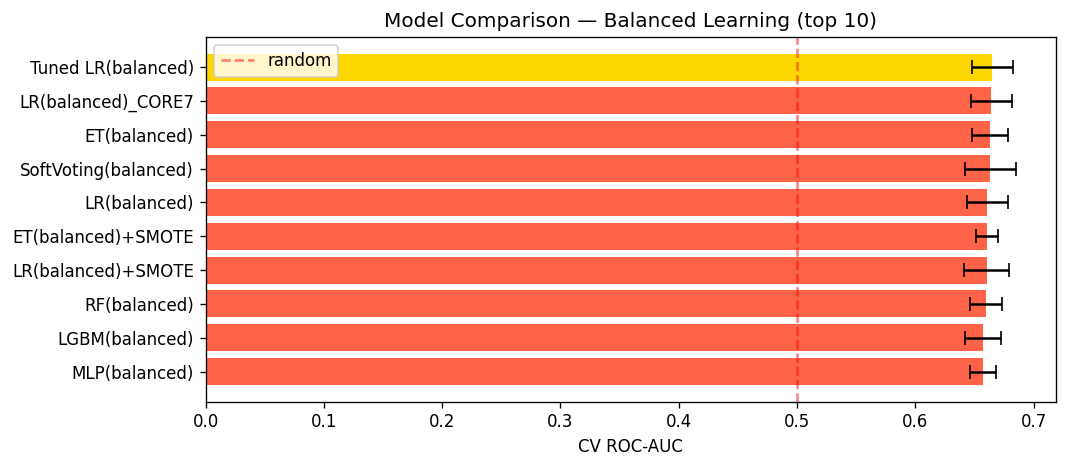

Saved: model3_comparison.png


In [14]:
# 비교 시각화
top10 = comp_df.head(10)
colors = ['gold' if m == champion_name else
          'tomato' if 'balanced' in m.lower() or 'SMOTE' in m else 'steelblue'
          for m in top10['Model']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top10['Model'][::-1], top10['CV AUC'][::-1],
        xerr=top10['AUC std'][::-1], color=colors[::-1], capsize=4)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='random')
ax.set_xlabel('CV ROC-AUC')
ax.set_title('Model Comparison — Balanced Learning (top 10)')
ax.legend()
plt.tight_layout()
plt.savefig('model3_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: model3_comparison.png')

## 8. answer3.csv — Train OOF 이진 예측 (threshold=0.5 고정)

In [15]:
print('OOF 예측 생성 중... (threshold=0.5 고정)')

# 새 파이프라인 인스턴스로 OOF (fit된 파이프 재사용 불가)
if champion_name == f'Tuned {tune_name}':
    oof_pipe = build_pipe(best_feats, tuned_clf.__class__(**tuned_clf.get_params()),
                          scale=tune_scale, smote=best_smote)
elif champion_name == 'SoftVoting(balanced)':
    # Voter는 cross_val_predict가 느릴 수 있으므로 tuned 모델로 대체
    oof_pipe = build_pipe(best_feats, tuned_clf.__class__(**tuned_clf.get_params()),
                          scale=tune_scale, smote=best_smote)
    print('(SoftVoting OOF → tuned 모델로 근사)')
else:
    base = champion_name.replace('+SMOTE','').replace('_CORE7','')
    c, ns = candidates.get(base, list(candidates.values())[0])
    oof_pipe = build_pipe(best_feats, c.__class__(**c.get_params()),
                          scale=ns, smote=('+SMOTE' in champion_name))

oof_proba = cross_val_predict(
    oof_pipe, train[best_feats], train['target'],
    cv=CV, method='predict_proba', n_jobs=-1
)[:, 1]

oof_binary = (oof_proba >= THRESHOLD).astype(int)   # threshold=0.5 고정

oof_auc  = roc_auc_score(train['target'], oof_proba)
oof_acc  = accuracy_score(train['target'], oof_binary)
oof_bacc = balanced_accuracy_score(train['target'], oof_binary)
oof_f1   = f1_score(train['target'], oof_binary, average='macro')

print(f'OOF AUC={oof_auc:.4f}  Acc={oof_acc:.4f}  BalAcc={oof_bacc:.4f}  F1={oof_f1:.4f}')
print(f'OOF 예측 분포: 0={int((oof_binary==0).sum())}  1={int((oof_binary==1).sum())}')
print(f'실제 분포:     0={(train["target"]==0).sum()}  1={(train["target"]==1).sum()}')

answer3 = pd.DataFrame({'id': train['id'], 'target': oof_binary})
answer3.to_csv('answer3.csv', index=False)
print(f'Saved: answer3.csv  ({len(answer3)}행)')

OOF 예측 생성 중... (threshold=0.5 고정)
OOF AUC=0.6646  Acc=0.7019  BalAcc=0.6519  F1=0.6564
OOF 예측 분포: 0=7071  1=2929
실제 분포:     0=6568  1=3432
Saved: answer3.csv  (10000행)


## 9. subfinal3.csv — Test 이진 예측 (threshold=0.5 고정)

In [16]:
if test is not None:
    X_test = test[best_feats]

    test_proba  = champion_pipe.predict_proba(X_test)[:, 1]
    test_binary = (test_proba >= THRESHOLD).astype(int)   # threshold=0.5 고정

    subfinal3 = pd.DataFrame({'id': test['id'], 'target': test_binary})

    if os.path.exists('sample_submission.csv'):
        ss = pd.read_csv('sample_submission.csv')
        subfinal3 = subfinal3[ss.columns]

    subfinal3.to_csv('subfinal3.csv', index=False)
    print(f'Saved: subfinal3.csv  ({len(subfinal3)}행)')
    print(f'예측 분포: 0={int((subfinal3["target"]==0).sum())}  1={int((subfinal3["target"]==1).sum())}')
    print(f'예측 1 비율: {subfinal3["target"].mean():.4f}  (test 실제 1 비율 ≈ 0.488)')
    print(subfinal3.head())
else:
    print('test.csv 없음')

Saved: subfinal3.csv  (2000행)
예측 분포: 0=1116  1=884
예측 1 비율: 0.4420  (test 실제 1 비율 ≈ 0.488)
      id  target
0  10097       0
1  11150       1
2  11596       1
3  11007       1
4  10120       0


## 10. 최종 요약

In [17]:
print('=' * 65)
print('Model 3 — Balanced Learning 완료')
print('=' * 65)
print(f'Champion     : {champion_name}')
print(f'Tier         : {best_tier_name}  ({len(best_feats)}개 feature)')
print(f'CV AUC       : {champion_auc:.4f}')
print(f'OOF AUC      : {oof_auc:.4f}')
print(f'OOF Acc      : {oof_acc:.4f}  (threshold=0.5)')
print(f'OOF BalAcc   : {oof_bacc:.4f}')
print()
print('Test 예측 분포 확인 (기대: ~0.488이 1):')
if test is not None:
    ratio = test_binary.mean()
    print(f'  예측 1 비율 = {ratio:.4f}  '
          + ('OK' if 0.35 < ratio < 0.65 else 'WARNING: 비율 이상'))
print()
print('산출물:')
for f in ['answer3.csv','subfinal3.csv','model3_comparison.png']:
    print(f'  [{"O" if os.path.exists(f) else "X"}] {f}')

Model 3 — Balanced Learning 완료
Champion     : Tuned LR(balanced)
Tier         : CORE7  (6개 feature)
CV AUC       : 0.6650
OOF AUC      : 0.6646
OOF Acc      : 0.7019  (threshold=0.5)
OOF BalAcc   : 0.6519

Test 예측 분포 확인 (기대: ~0.488이 1):
  예측 1 비율 = 0.4420  OK

산출물:
  [O] answer3.csv
  [O] subfinal3.csv
  [O] model3_comparison.png
